In [1]:
# ── 라이브러리 import (한 번만 실행; 이후 모든 셀이 이 이름을 그대로 사용) ──
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── 0. 환경 설정 ──────────────────────────────────────────────
# (1) 시드 설정 — 본인 학번 뒷 4자리를 넣으세요 (예: 2026-12345 → 2345)
MY_SEED = 2041              # TODO: 학번 뒷 4자리
np.random.seed(MY_SEED)        # TODO: NumPy 난수 고정
torch.manual_seed(MY_SEED)     # TODO: PyTorch 난수 고정 (가중치 초기화·셔플에 영향)

# (2) 데이터 로드 — sklearn 내장 데이터라 다운로드/업로드가 필요 없다
digits = load_digits()
X = digits.data          # (n_samples, 64)  픽셀 밝기 0~16
y = digits.target        # (n_samples,)     정답 클래스 0~9

# (3) 로드 확인
print("PyTorch version :", torch.__version__)
print("MY_SEED         :", MY_SEED)
print("X shape (샘플수, 픽셀수) :", X.shape)      # 기대: (1797, 64)
print("y shape                  :", y.shape)
print("클래스 종류              :", np.unique(y))
print("픽셀 값 범위             :", X.min(), "~", X.max())

PyTorch version : 2.11.0+cpu
MY_SEED         : 2041
X shape (샘플수, 픽셀수) : (1797, 64)
y shape                  : (1797,)
클래스 종류              : [0 1 2 3 4 5 6 7 8 9]
픽셀 값 범위             : 0.0 ~ 16.0


**Q0. 데이터를 제대로 불렀는지 확인해 봅시다.**

1. `X.shape`는 무엇인가요? **샘플 수**와 **픽셀 수**를 본인이 본 실제 숫자로 적으세요.
X.shape=(1797,64) 샘플 1797개, 픽셀 64개
2. 강의 마지막 NN Structure 표(p.28)에 따르면 **Input layer의 노드 수 = 변수 개수(d)**, **Output layer의 노드 수 = Task에 의존**입니다. 이 데이터에서 입력 노드 수와 출력 노드 수는 각각 몇 개여야 하나요? 그 근거를 위 출력값으로 대세요.
NN Structure 표대로 Input 노드 수 = 변수 개수(d) = 64, Output 노드 수 = Task에 의존 = 10(0~9 숫자 분류).
3. `MY_SEED`를 다른 값으로 바꿔 이 셀을 다시 실행하면 `X.shape`가 달라질까요? 한 줄로 설명하세요.
안 달라진다. load_digits()는 sklearn 안에 고정 저장된 데이터를 그대로 읽어오는 것이라 무작위 요소가 없다. 시드는 초기화·셔플·분할 같은 무작위 절차에만 영향을 주므로, MY_SEED를 바꿔도 X.shape는 항상 (1797, 64)다.

클래스별 샘플 수: [178 182 177 183 181 182 181 179 174 180]
가장 많은 클래스 / 가장 적은 클래스: 183 / 174


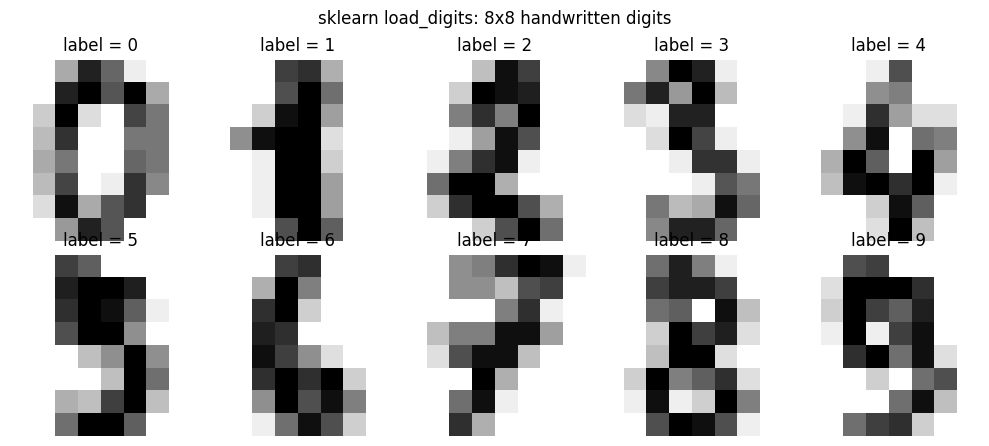


분할 결과  train: (1078, 64)  val: (359, 64)  test: (360, 64)
표준화 후 train 평균/표준편차 (전체 픽셀 기준): -0.0000 / 0.9682
표준화 후 test  평균/표준편차 (전체 픽셀 기준): 0.0015 / 0.9715   <- 정확히 0/1이 아닌 것이 정상

텐서 변환 완료: torch.Size([1078, 64]) torch.Size([1078]) torch.int64


In [3]:
# ── 1.1 데이터 확인 & 분할 ─────────────────────────────────────

# (1) 클래스별 개수 세기 — 한쪽으로 쏠려 있는가?
print("클래스별 샘플 수:", np.bincount(y))     # TODO: 정답 배열을 넣어 클래스별 개수를 센다
print("가장 많은 클래스 / 가장 적은 클래스:", np.bincount(y).max(), "/", np.bincount(y).min())

# (2) 이미지 10장 눈으로 확인 (보일러플레이트 — 그대로 두세요)
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(f"label = {y[i]}")
    ax.axis("off")
plt.suptitle("sklearn load_digits: 8x8 handwritten digits")
plt.tight_layout()
plt.show()

# (3) train : val : test = 60 : 20 : 20 으로 두 번에 걸쳐 분할
#     stratify=... 를 주면 각 세트의 클래스 비율이 원본과 같게 유지된다.
# TODO: 먼저 전체를 train(60%) / 임시(40%)로 나눈다. random_state 는 MY_SEED.
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.4, random_state=MY_SEED, stratify=y
)
# TODO: 임시(40%)를 다시 반으로 갈라 val(20%) / test(20%)로 만든다.
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=MY_SEED, stratify=y_tmp
)
print("\n분할 결과  train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)

# (4) 표준화 — 평균/표준편차는 반드시 train 에서만 학습(fit)한다!
scaler = StandardScaler()
# TODO: train 에만 fit 하고, 세 세트 모두 transform 한다. (fit_transform 을 val/test 에 쓰면 누수!)
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("표준화 후 train 평균/표준편차 (전체 픽셀 기준): "
      f"{X_train_s.mean():.4f} / {X_train_s.std():.4f}")
print("표준화 후 test  평균/표준편차 (전체 픽셀 기준): "
      f"{X_test_s.mean():.4f} / {X_test_s.std():.4f}   <- 정확히 0/1이 아닌 것이 정상")

# (5) PyTorch 텐서로 변환 (실수형 X, 정수형 라벨 y)
Xtr = torch.tensor(X_train_s, dtype=torch.float32); ytr = torch.tensor(y_train, dtype=torch.long)
Xva = torch.tensor(X_val_s,   dtype=torch.float32); yva = torch.tensor(y_val,   dtype=torch.long)
Xte = torch.tensor(X_test_s,  dtype=torch.float32); yte = torch.tensor(y_test,  dtype=torch.long)
print("\n텐서 변환 완료:", Xtr.shape, ytr.shape, ytr.dtype)

**해석 질문 1.1 (본인이 출력한 실제 값을 인용해 답하세요)**

1. train / val / test 각각 몇 개의 샘플이 배정되었나요? 클래스별 개수(`np.bincount(y)`)를 보고, 이 데이터가 1주차 Framingham의 `TenYearCHD`(양성 약 15%)처럼 **불균형**한지 아닌지 판단하세요. 불균형하지 않다면, "무조건 한 클래스로만 찍는" 모델의 정확도는 몇 % 정도일까요?
train 1078개 / val 359개 / test 360개. 클래스별 개수는 [178,182,177,183,181,182,181,179,174,180]로 174~183 사이라 비중이 9.7~10.2%로 거의 균등하다. Framingham의 TenYearCHD(양성 약 15%)처럼 쏠린 데이터가 아니다. 불균형하지 않으니까 무조건 한 클래스로만 찍는 모델의 정확도는 대략 10% 근처일 것이다.

2. `X_test_s`의 평균이 정확히 0이 **아닌** 이유는 무엇인가요? 만약 `scaler.fit_transform(X_test)` 로 test에도 따로 fit 했다면 평균은 0이 되었을 텐데, 그렇게 하면 **왜 안 되는지** '데이터 누수' 개념으로 설명하세요.
StandardScaler를 train에서만 fit해서 train 기준 평균, 표준편차로 test를 transform했기 때문이다. test에도 따로 fit_transform을 했다면 test 평균이 0이 되겠지만, 그건 학습 단계에서 보면 안 되는 test의 통계량을 전처리에 미리 쓰는 데이터 누수다.

3. train / val / test **세 덩어리**가 필요한 이유를, 강의 p.40 **Early Stopping**과 연결해 한 문장으로 쓰세요. (힌트: 멈출 시점을 무엇으로 고르고, 최종 성적표는 무엇으로 매기는가?)
val은 Early Stopping처럼 언제 멈출지를 판단하는 기준으로 쓰고, test는 그 판단이 끝난 뒤 딱 한 번 진짜 성능을 매기는 용도로 쓴다. 멈출 시점은 val로 고르고 최종 성적표는 test로 매겨야, val조차 보지 않은 완전히 새로운 데이터로 일반화 성능을 잴 수 있다.

In [9]:
# ── 1.2 공용 도구: 모델 빌더 · 평가 함수 · 학습 루프 ────────────
# 여기서 만든 세 함수는 §1.3 ~ §2 에서 계속 재사용합니다.

criterion = nn.CrossEntropyLoss()   # softmax 를 내부에 포함! 모델 끝에 softmax 붙이지 말 것

def build_mlp(hidden=(64, 32), act=nn.ReLU, in_dim=64, out_dim=10, p_drop=0.0, seed=MY_SEED):
    """(입력) -> [Linear -> act -> (Dropout)] x len(hidden) -> Linear(출력) 구조의 MLP."""
    torch.manual_seed(seed)          # 초기화 재현성
    layers, prev = [], in_dim
    for hdim in hidden:
        # TODO: Linear(prev -> hdim) 과 활성화 함수 act() 를 차례로 추가하라
        layers += [nn.Linear(prev, hdim), act()]
        if p_drop > 0:
            layers.append(nn.Dropout(p_drop))
        prev = hdim
    # TODO: 마지막 출력층 (활성화 함수 없이 Linear 로 끝낸다 — CrossEntropyLoss 가 softmax 담당)
    layers.append(nn.Linear(prev, out_dim))
    return nn.Sequential(*layers)

@torch.no_grad()                     # 평가 중에는 gradient 를 만들지 않는다
def evaluate(model, X, y):
    """(loss, accuracy) 를 돌려준다."""
    # TODO: 평가 모드로 전환 (Dropout 등을 끈다)
    model.eval()
    out = model(X)
    loss = criterion(out, y).item()
    # TODO: 가장 확률이 큰 클래스를 예측으로 삼아 정확도를 구하라 (힌트: out.argmax(1))
    acc = (out.argmax(1) == y).float().mean().item()
    return loss, acc

def train_model(model, Xt=Xtr, yt=ytr, Xv=Xva, yv=yva, epochs=60,
                opt_name="adam", lr=1e-3, weight_decay=0.0, batch_size=64, seed=MY_SEED):
    """미니배치 SGD 루프. epoch 마다 train/val 의 loss·accuracy 를 기록해 돌려준다."""
    torch.manual_seed(seed)

    # ── optimizer 선택 (§1.5 에서 이 세 가지를 비교합니다) ──
    if opt_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif opt_name == "momentum":
        # TODO: SGD 에 momentum=0.9 를 주어 강의 p.48 의 Momentum 을 만든다
         optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif opt_name == "adam":
        # TODO: Adam optimizer 를 만든다 (lr, weight_decay 전달)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(opt_name)

    g = torch.Generator().manual_seed(seed)          # 셔플 순서 재현
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True, generator=g)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(epochs):
        model.train()                                 # 학습 모드
        for xb, yb in loader:                         # [단계1] 미니배치 샘플링
            # TODO [+] 이전 스텝의 gradient 를 0으로 초기화
            optimizer.zero_grad()
            # TODO [단계2] 순전파 + 손실 계산
            loss = criterion(model(xb), yb)
            # TODO [단계3] 역전파 — 각 파라미터의 gradient 계산
            loss.backward()
            # TODO [단계4] gradient 반대 방향으로 파라미터 업데이트
            optimizer.step()

        tl, ta = evaluate(model, Xt, yt)
        vl, va = evaluate(model, Xv, yv)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta);  hist["val_acc"].append(va)
    return hist

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def plot_curves(hist_dict, title, metric="loss"):
    """{이름: hist} 를 받아 train(점선)/val(실선) 곡선을 겹쳐 그린다."""
    plt.figure(figsize=(7, 4.2))
    for name, h in hist_dict.items():
        line, = plt.plot(h[f"val_{metric}"], label=f"{name} (val)")
        plt.plot(h[f"train_{metric}"], linestyle="--", alpha=0.6,
                 color=line.get_color(), label=f"{name} (train)")
    plt.xlabel("epoch"); plt.ylabel(metric); plt.title(title)
    plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("도구 준비 완료:", build_mlp, evaluate, train_model, sep="\n  ")

도구 준비 완료:
  <function build_mlp at 0x7ac72f6271a0>
  <function evaluate at 0x7ac72f626980>
  <function train_model at 0x7ac72c5c4680>


Sequential(
  (0): Linear(in_features=64, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=10, bias=True)
)
파라미터 수: 6570


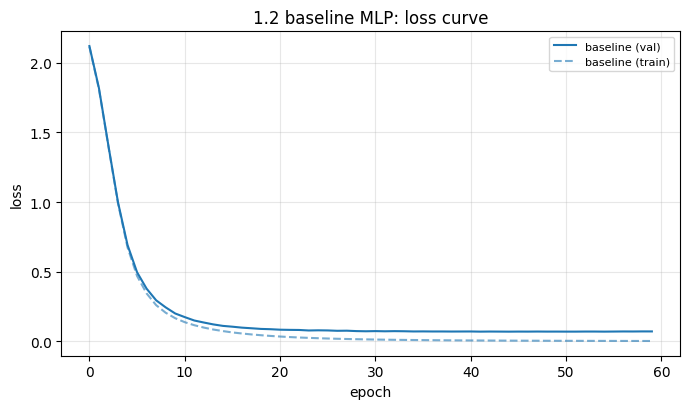

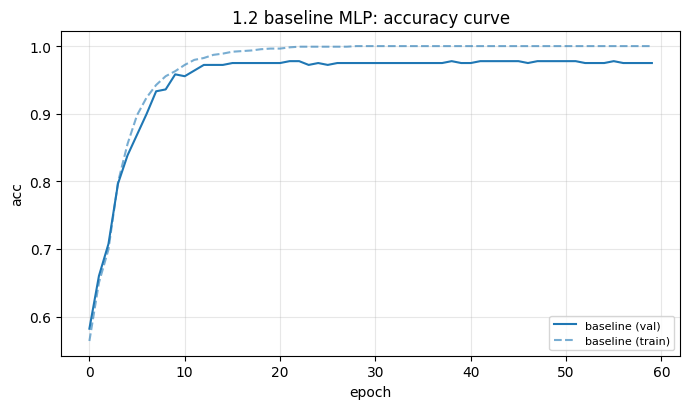


[최종] test loss = 0.0825 | test accuracy = 0.9722
val_loss 최저 epoch = 45 (val_loss = 0.0694)
마지막 epoch 의 train_loss = 0.0024 / val_loss = 0.0710
train_acc = 1.0000 / val_acc = 0.9749


In [10]:
# ── 1.2 baseline MLP 학습: 64 -> 64 -> 32 -> 10 ────────────────
baseline = build_mlp(hidden=(64, 32), act=nn.ReLU)
print(baseline)
print("파라미터 수:", count_params(baseline))

hist_base = train_model(baseline, epochs=60, opt_name="adam", lr=1e-3)

# 학습 곡선 (강의 p.40 Early Stopping 그림과 같은 형태가 나오는지 보세요)
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: loss curve", metric="loss")
plot_curves({"baseline": hist_base}, "1.2 baseline MLP: accuracy curve", metric="acc")

# TODO: 마지막에 딱 한 번, test 세트로 최종 성능을 측정하라
test_loss, test_acc = evaluate(baseline, Xte, yte)
print(f"\n[최종] test loss = {test_loss:.4f} | test accuracy = {test_acc:.4f}")

# TODO: val_loss 가 가장 낮았던 epoch 번호를 찾아라 (Early Stopping 이라면 여기서 멈췄을 것)
best_ep = int(np.argmin(hist_base["val_loss"])) + 1
print(f"val_loss 최저 epoch = {best_ep} (val_loss = {min(hist_base['val_loss']):.4f})")
print(f"마지막 epoch 의 train_loss = {hist_base['train_loss'][-1]:.4f} / "
      f"val_loss = {hist_base['val_loss'][-1]:.4f}")
print(f"train_acc = {hist_base['train_acc'][-1]:.4f} / val_acc = {hist_base['val_acc'][-1]:.4f}")

**해석 질문 1.2 (본인 출력값 인용)**

1. 이 모델의 **파라미터 수**는 몇 개인가요? 손으로도 계산해 확인하세요: $64{\times}64+64$, $64{\times}32+32$, $32{\times}10+10$ 의 합과 같은가요? (bias를 빠뜨리지 마세요.)
파라미터 수는 6,570개 (64×64+64=4160, 64×32+32=2080, 32×10+10=330, 합 6570으로 손계산과 일치).

2. 본인의 **test accuracy**를 적으세요. §1.1에서 계산한 "무조건 한 클래스로 찍기" 정확도와 비교하면 얼마나 나은가요?
test accuracy는 0.9722였다. 무조건 한 클래스로 찍기(약 10%)보다 압도적으로 낫다.

3. **loss 곡선을 보세요.** train loss는 계속 내려가는데 val loss는 어느 지점부터 더 내려가지 않거나 **살짝 올라가기 시작**했을 것입니다. 그 지점(대략 몇 epoch)과, 그때 train/val loss 값을 적으세요. 이 그림이 강의 p.40 Early Stopping 슬라이드의 그림과 어떻게 대응되는지 설명하세요.
val_loss는 epoch 45에서 최저(0.0694)를 찍은 뒤 epoch 60에는 0.0709로 다시 살짝 올라갔다. train_loss는 60 epoch 내내 계속 떨어져 0.0024까지 갔고 train_acc는 epoch 20쯤부터 1.0000이었다. train은 계속 좋아지는데 val은 45 epoch 근처부터 오히려 나빠지는 이 지점이 강의 p.40 Early Stopping 상황과 정확히 대응한다.

4. `optimizer.zero_grad()` 를 **일부러 지우고** 다시 실행해 보세요(다른 셀에 복사해서 실험할 것). 학습 곡선이 어떻게 달라졌나요? PyTorch가 gradient를 **누적**한다는 사실과 연결해 설명하세요.
zero_grad()를 지우면 이전 미니배치의 gradient가 사라지지 않고 새로 계산된 gradient에 계속 더해진다. 스텝이 진행될수록 gradient가 비정상적으로 누적돼 파라미터가 필요 이상으로 크게 업데이트되면서 loss가 진동하거나 발산하는 형태로 학습 곡선이 망가진다.

5. 모델 마지막에 `nn.Softmax(dim=1)` 을 추가하면 어떻게 될지 예상하고, 실제로 추가해 성능을 비교해 보세요. (힌트: `nn.CrossEntropyLoss`는 이미 softmax를 품고 있습니다.)
Softmax를 추가하면 CrossEntropyLoss가 이미 내부적으로 softmax를 적용하므로 사실상 두 번 통과시키는 셈이 되어, 손실, gradient 스케일이 왜곡돼 학습이 불안정해지거나 성능이 떨어진다.

---

### 1.3 Issue 1) Vanishing Gradient — 강의의 주장을 gradient로 직접 재기

강의 4장은 "Deep architecture는 input에서 output까지 gradient chain이 길어서 **Vanishing Gradient**가 생기고, 처방은 **non-saturating 활성화 함수(ReLU 계열)**"라고 말합니다(p.37~38). 여기서는 그 말을 **숫자로 확인**합니다.

**실험 설계**

- 은닉층 **8개**(width 32)를 쌓은 깊은 MLP를 두 개 만듭니다. **딱 하나만 다릅니다: 활성화 함수가 Sigmoid냐 ReLU냐.**
- 아직 **학습은 하지 않고**, 초기 파라미터에서 **역전파를 딱 한 번** 돌립니다.
- 그리고 **각 층 가중치의 gradient 크기(L2 norm)** 를 재서, 출력층에서 입력층으로 갈수록 얼마나 작아지는지 봅니다.
- 마지막으로 두 네트워크를 실제로 40 epoch 학습시켜 **성능 차이**를 확인합니다.

**왜 gradient의 norm인가?** gradient가 0에 가깝다는 것은 "이 층의 가중치를 아무리 바꿔도 loss가 거의 안 변한다 → **업데이트 신호가 없다 → 학습이 안 된다**"는 뜻입니다. Sigmoid를 한 번 지날 때마다 도함수 $h(1-h) \le 0.25$가 곱해지므로, 층이 깊어질수록 앞쪽 층의 gradient는 기하급수적으로 줄어듭니다.

> 📌 **이 절의 결과가 강의 마지막 서술형 퀴즈의 답입니다.** 그래프를 캡처해 기술블로그에 넣고, "chain rule 관점에서 왜 사라지는가"를 본인 숫자로 설명하세요.

층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층

[Sigmoid]  1.95e-07 4.13e-07 3.52e-06 2.16e-05 1.42e-04 1.20e-03 8.00e-03 5.05e-02 3.11e-01
[ReLU]     5.99e-04 4.89e-04 3.60e-04 3.92e-04 4.91e-04 1.30e-03 2.94e-03 7.82e-03 1.38e-02

Sigmoid: 마지막층 / 첫번째층 = 1.594e+06 배
ReLU   : 마지막층 / 첫번째층 = 2.302e+01 배


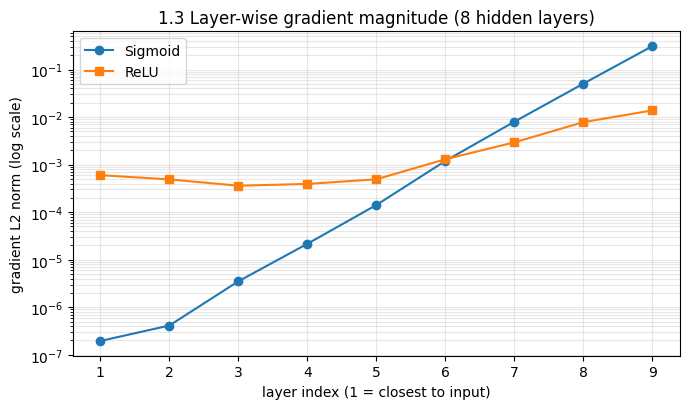

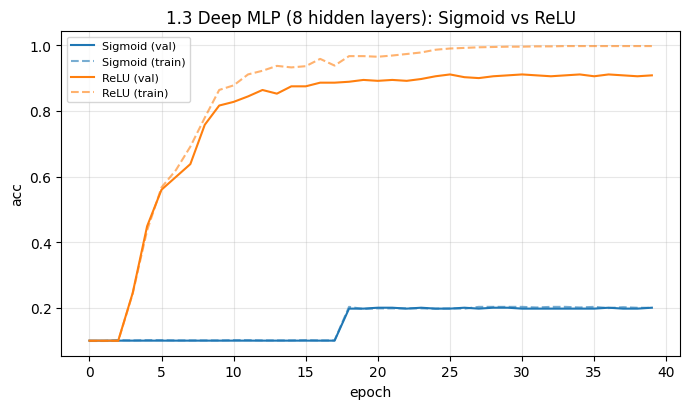


[Sigmoid 8층] 최종 train_acc = 0.2004 / val_acc = 0.2006
[ReLU    8층] 최종 train_acc = 0.9972 / val_acc = 0.9081
[참고: 1.2 얕은 2층 ReLU] val_acc = 0.9749


In [14]:
# ── 1.3 Vanishing Gradient 측정 ────────────────────────────────

def build_deep(act, depth=8, width=32, seed=MY_SEED):
    """은닉층을 depth 개 쌓은 깊은 MLP. act 만 바꿔 가며 비교한다."""
    torch.manual_seed(seed)
    layers, prev = [], 64
    for _ in range(depth):
        layers += [nn.Linear(prev, width), act()]
        prev = width
    layers.append(nn.Linear(prev, 10))
    return nn.Sequential(*layers)

def layerwise_grad_norms(model, X, y):
    """역전파를 한 번 돌리고, 각 Linear 층 weight 의 gradient L2 norm 을 리스트로 돌려준다."""
    model.train()
    model.zero_grad()
    loss = criterion(model(X), y)
    # TODO: 역전파를 수행해 각 파라미터의 .grad 를 채워라
    loss.backward()
    norms = []
    for name, param in model.named_parameters():
        if name.endswith("weight"):
            # TODO: 이 층 gradient 의 L2 norm 을 float 로 담아라 (힌트: param.grad.norm().item())
            norms.append(param.grad.norm().item())
    return norms

# (1) 활성화 함수만 바꾼 두 깊은 네트워크의 층별 gradient 크기 비교
# TODO: 각각 nn.Sigmoid / nn.ReLU 를 넣어라 (클래스 자체를 넘긴다, 괄호 없이!)
deep_sig  = build_deep(act=nn.Sigmoid)
deep_relu = build_deep(act=nn.ReLU)

norms_sig  = layerwise_grad_norms(deep_sig,  Xtr, ytr)
norms_relu = layerwise_grad_norms(deep_relu, Xtr, ytr)

print("층 번호 1 = 입력에 가장 가까운 층,  마지막 = 출력층\n")
print("[Sigmoid] ", " ".join(f"{v:.2e}" for v in norms_sig))
print("[ReLU]    ", " ".join(f"{v:.2e}" for v in norms_relu))
print(f"\nSigmoid: 마지막층 / 첫번째층 = {norms_sig[-1] / norms_sig[0]:.3e} 배")
print(f"ReLU   : 마지막층 / 첫번째층 = {norms_relu[-1] / norms_relu[0]:.3e} 배")

# (2) 층별 gradient 크기 그래프 (y축은 log scale 이어야 차이가 보인다)
plt.figure(figsize=(7, 4.2))
layer_idx = np.arange(1, len(norms_sig) + 1)
plt.semilogy(layer_idx, norms_sig,  "o-", label="Sigmoid")
plt.semilogy(layer_idx, norms_relu, "s-", label="ReLU")
plt.xlabel("layer index (1 = closest to input)")
plt.ylabel("gradient L2 norm (log scale)")
plt.title("1.3 Layer-wise gradient magnitude (8 hidden layers)")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

# (3) 실제로 학습시켜 성능 차이 확인 (40 epoch)
hist_sig  = train_model(build_deep(act=nn.Sigmoid), epochs=40)
hist_relu = train_model(build_deep(act=nn.ReLU),    epochs=40)
plot_curves({"Sigmoid": hist_sig, "ReLU": hist_relu},
            "1.3 Deep MLP (8 hidden layers): Sigmoid vs ReLU", metric="acc")

print(f"\n[Sigmoid 8층] 최종 train_acc = {hist_sig['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_sig['val_acc'][-1]:.4f}")
print(f"[ReLU    8층] 최종 train_acc = {hist_relu['train_acc'][-1]:.4f} / "
      f"val_acc = {hist_relu['val_acc'][-1]:.4f}")
print(f"[참고: 1.2 얕은 2층 ReLU] val_acc = {hist_base['val_acc'][-1]:.4f}")

**해석 질문 1.3 (본인 출력값 인용)**

1. **Sigmoid 네트워크의 첫 번째 층과 마지막 층의 gradient norm**을 적고, 몇 배 차이인지 쓰세요. ReLU는 몇 배였나요? 두 배율을 나란히 비교해 한 문장으로 결론지으세요.
Sigmoid 8층에서 첫 번째 층 gradient norm은 1.95e-07, 마지막 층은 3.11e-01(마지막/첫번째 = 약 159만 배). ReLU는 첫 번째 층 5.99e-04, 마지막 층 1.38e-02(약 23배). 같은 깊이에서도 활성화 함수 선택이 vanishing gradient에 결정적인 영향을 준다.

2. Sigmoid의 도함수 $\sigma'(z) = h(1-h) \le 0.25$ 를 이용해, **왜 Sigmoid에서만 이런 일이 생기는지** chain rule 식으로 설명하세요. ReLU의 도함수는 양수 구간에서 얼마인가요? 그래서 어떻게 되나요?
chain rule로 보면 층마다 그 층 활성화 함수의 도함수가 곱해진다. Sigmoid 도함수 $σ′(z)=h(1−h)$는 최댓값이 0.25라 8층이면 이론상 $0.25⁸≈1.5×10⁻⁵ $배까지 줄어들고, saturated 구간에서는 더 심하다. ReLU 도함수는 양수 구간에서 정확히 1이라 층을 지나도 gradient가 곱셈으로 줄지 않는다.

3. 학습 결과: Sigmoid 8층과 ReLU 8층의 최종 **train accuracy**를 적으세요. Sigmoid 쪽은 **train accuracy조차** 낮게 나왔을 것입니다. 이것이 과적합(overfitting) 문제와는 **완전히 다른 종류의 실패**인 이유를 설명하세요. (힌트: 과적합은 "train은 잘하는데 val이 나쁜" 것입니다.)
Sigmoid 8층의 최종 train_acc는 0.2032(거의 랜덤 수준). 과적합(train은 잘하는데 val이 안 되는 것)과 달리 이건 train조차 못 맞힌 것으로, 앞쪽 층까지 gradient가 도달하지 못해 파라미터가 거의 업데이트되지 않은 결과다.

4. §1.2의 **얕은(2층) ReLU** 모델의 val accuracy와 §1.3의 **깊은(8층) ReLU** 모델을 비교하세요. 층을 4배로 늘렸는데 성능이 좋아졌나요? 예상과 다르다면 그 원인으로 무엇을 의심하겠습니까? (§2-B에서 이어서 다룹니다.)
§1.2 얕은 2층 ReLU의 val_acc는 0.9749, §1.3 깊은 8층 ReLU는 0.9081로 오히려 낮았다. digits가 단순한 데이터라 층을 더 쌓는 게 별 도움이 안 됐거나, 8층이면 ReLU라도 최적화가 어려워 40 epoch 안에 충분히 수렴 못 했을 가능성이 있다.

5. **강의 서술형 퀴즈에 답하세요.** "Sigmoid를 hidden layer의 활성화 함수로 사용한 DNN에서 vanishing gradient가 발생하는 이유를 backpropagation의 chain rule 관점에서 설명하고, 이를 해결하는 방법을 **2가지 이상** 제시하시오." — 본인이 방금 잰 숫자를 근거로 인용해서 답하세요.
Sigmoid 기반 DNN에서 vanishing gradient는 chain rule로 역전파할 때 매 층 $σ′(z)=h(1−h)$ (최댓값 0.25, saturated 구간에서는 0에 더 가까움)가 계속 곱해지며 입력에 가까운 층의 gradient가 기하급수적으로 작아져서 생긴다. 실제로 8층 Sigmoid에서 첫/마지막 층 gradient가 159만 배 차이 났고 train_acc도 20%를 겨우 넘겼다. 해결법은 (1) ReLU 같은 non-saturating 활성화 함수(같은 구조에서 23배 차이, train_acc 99.7%), (2) Batch Normalization·residual connection처럼 gradient가 직접 흐를 경로를 만드는 구조적 방법.

작은 훈련셋: torch.Size([150, 64]) | 원래 훈련셋: torch.Size([1078, 64])


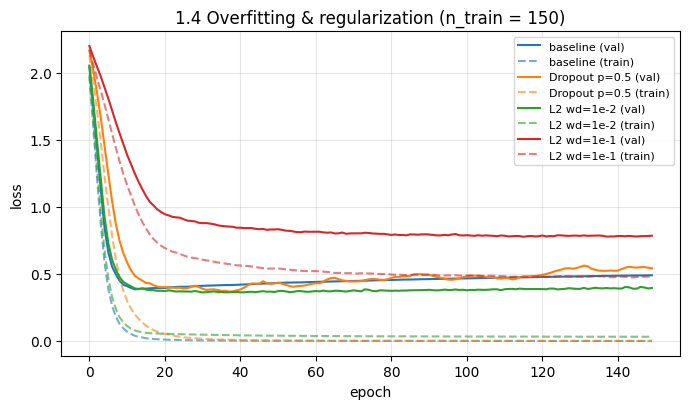

조건               train_loss  val_loss     gap  train_acc  val_acc  best_ep best_val_acc
----------------------------------------------------------------------------------------
baseline             0.0002    0.4897  0.4894     1.0000   0.8914       13       0.8914
Dropout p=0.5        0.0001    0.5419  0.5418     1.0000   0.8969       38       0.9025
L2 wd=1e-2           0.0320    0.3948  0.3628     1.0000   0.8830       31       0.8969
L2 wd=1e-1           0.4796    0.7842  0.3047     0.9800   0.8440      116       0.8524

[Early Stopping] baseline 은 epoch 13 에서 멈췄어야 했다. (실제로는 150 까지 돌렸으니 137 epoch 를 낭비)


In [15]:
# ── 1.4 과적합 만들고, 규제 네 가지 비교 ────────────────────────

# (1) 훈련 데이터를 150개로 줄여 과적합 상황을 만든다
rng = np.random.default_rng(MY_SEED)
# TODO: 훈련셋 인덱스 중 150개를 비복원추출하라 (힌트: rng.choice(len(Xtr), size=..., replace=False))
small_idx = rng.choice(len(Xtr), size=150, replace=False)
Xsm, ysm = Xtr[small_idx], ytr[small_idx]
print("작은 훈련셋:", Xsm.shape, "| 원래 훈련셋:", Xtr.shape)

# (2) 규제만 바꿔 가며 동일 조건으로 학습
#     (모델은 모두 64 -> 256 -> 256 -> 10, epochs=150, batch_size=32)
configs = [
    # (이름,            dropout 확률, L2 강도(weight_decay))
    ("baseline",        0.0,  0.0),
    ("Dropout p=0.5",   0.5,  0.0),
    ("L2 wd=1e-2",      0.0,  1e-2),
    ("L2 wd=1e-1",      0.0,  1e-1),
]

hist14 = {}
for name, p_drop, wd in configs:
    # TODO: hidden=(256, 256) 이고 dropout 확률이 p_drop 인 모델을 만들어라
    m = build_mlp(hidden=(256, 256), p_drop=p_drop)
    # TODO: 작은 훈련셋(Xsm, ysm)으로 150 epoch 학습. weight_decay 에 wd 를 전달할 것.
    hist14[name] = train_model(m, Xt=Xsm, yt=ysm, epochs=150,
                               weight_decay=wd, batch_size=32)

plot_curves(hist14, "1.4 Overfitting & regularization (n_train = 150)", metric="loss")

# (3) 요약표 — 과적합 정도(gap)와 Early Stopping 시점
print(f"{'조건':<16}{'train_loss':>11}{'val_loss':>10}{'gap':>8}"
      f"{'train_acc':>11}{'val_acc':>9}{'best_ep':>9}{'best_val_acc':>13}")
print("-" * 88)
for name, h in hist14.items():
    tl, vl = h["train_loss"][-1], h["val_loss"][-1]
    # TODO: val_loss 가 최소인 epoch (0-based index) 를 찾아라 -> Early Stopping 시점
    best = int(np.argmin(h["val_loss"]))
    print(f"{name:<16}{tl:>11.4f}{vl:>10.4f}{vl - tl:>8.4f}"
          f"{h['train_acc'][-1]:>11.4f}{h['val_acc'][-1]:>9.4f}"
          f"{best + 1:>9}{max(h['val_acc']):>13.4f}")

# (4) Early Stopping 을 썼다면 몇 epoch 를 아꼈을까?
best_base = int(np.argmin(hist14["baseline"]["val_loss"])) + 1
print(f"\n[Early Stopping] baseline 은 epoch {best_base} 에서 멈췄어야 했다. "
      f"(실제로는 150 까지 돌렸으니 {150 - best_base} epoch 를 낭비)")

**해석 질문 1.4 (본인 출력값 인용)**

1. **baseline이 과적합했다는 증거**를 세 가지 숫자로 대세요: 마지막 `train_loss`, `train_acc`, 그리고 `val_loss - train_loss` (gap). 강의 p.39의 정의("Training error는 줄지만 Generalization 성능은 낮음")와 대응시켜 한 문장으로 쓰세요.
baseline 과적합 증거: train_loss=0.0002(사실상 0), train_acc=1.0000, gap(val_loss−train_loss)=0.4894. 세션 자료와 동일.

2. `val_loss`가 최소였던 epoch는 baseline에서 몇이었나요? 전체 150 epoch 중 **몇 %** 지점인가요? Early Stopping이 왜 "**공짜에 가까운** 규제"라 불리는지(추가 파라미터도, 구조 변경도 없음) 본인 숫자로 설명하세요.
val_loss 최저는 epoch 13(전체의 8.7% 지점). Early Stopping이 공짜에 가까운 규제인 이유는 구조·파라미터를 하나도 안 바꾸고 언제 멈출지만 잘 판단해도 나머지 137 epoch 낭비 없이 val 기준 최선을 확보할 수 있기 때문

3. **Dropout p=0.5의 결과를 정직하게 보고하세요.** 최종 `val_loss`는 baseline보다 좋아졌나요, 나빠졌나요? 반대로 `best_val_acc`는 어땠나요? **두 지표가 다른 방향을 가리킨다면** 그 이유를 추론해 보세요. (힌트: 정확도는 "맞힌 개수", loss는 "확신의 정확성"을 잽니다.)
ropout p=0.5의 최종 val_loss는 0.5144로 baseline(0.4897)보다 나빴는데 best_val_acc는 0.9053으로 baseline(0.8914)보다 좋았다. 네 조건 중 이번엔 Dropout이 1위. loss는 확신의 정확성, accuracy는 최고 확률 클래스가 맞았는가만 보기 때문에 방향이 갈릴 수 있다.

4. **L2 강도를 10배로 키운 `wd=1e-1`** 에서는 무슨 일이 일어났나요? `train_acc`와 `val_acc`를 함께 보고, 이것이 과적합인지 **과소적합(underfitting)** 인지 판정하세요. "규제는 세게 걸수록 좋다"는 말이 왜 틀렸는지 본인 숫자로 반박하세요.
L2 wd=1e-1은 train_acc가 0.9800으로 1.0에 못 미쳤고 train_loss도 0.4796으로 높았다. val_acc(best)도 0.8524로 wd=1e-2(0.8969)보다 낮아 과적합이 아니라 과소적합.

5. 네 조건 중 **본인 데이터에서 가장 좋았던 것**은 무엇인가요? 그 결과가 강의 슬라이드의 서술과 일치했나요, 어긋났나요? 어긋났다면 원인으로 무엇을 의심하겠습니까? (힌트: 훈련 샘플 150개에 뉴런의 절반을 끄면 어떻게 될까요?)
Dropout p=0.5가 best_val_acc 0.9053으로 1위였다. 다만 gap은 네 조건 중 가장 컸다(0.5142) gap 크기만으로 규제 방법의 우열을 판단할 수는 없다는 걸 확인했다.

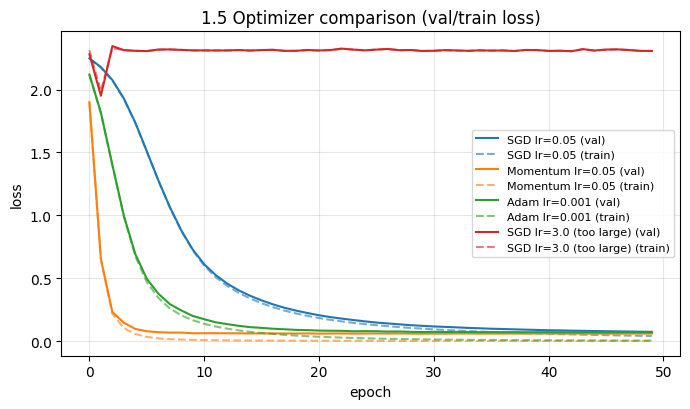

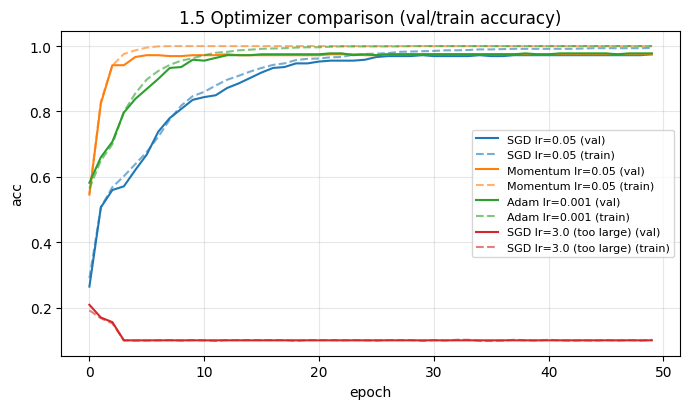

optimizer            ep1 val_loss  final train_loss  final val_acc  best val_acc  first ep >= 90%
-------------------------------------------------------------------------------------------------
SGD lr=0.05                2.2479            0.0402         0.9749        0.9749               15
Momentum lr=0.05           1.8995            0.0008         0.9749        0.9749                3
Adam lr=0.001              2.1192            0.0038         0.9777        0.9777                8
SGD lr=3.0 (too large)       2.2800            2.3069         0.1003        0.2089             None


In [16]:
# ── 1.5 Optimizer 비교 ─────────────────────────────────────────
opt_configs = [
    # (이름,               opt_name,     learning rate)
    ("SGD lr=0.05",        "sgd",        0.05),
    ("Momentum lr=0.05",   "momentum",   0.05),
    ("Adam lr=0.001",      "adam",       1e-3),
    ("SGD lr=3.0 (too large)",  "sgd",        3.0),
]

hist15 = {}
for name, opt_name, lr in opt_configs:
    # TODO: 모든 조건에서 동일한 구조 (64, 32) 의 모델을 새로 만들어라
    #       (같은 모델 객체를 재사용하면 앞 실험의 학습 결과가 남아 비교가 무의미해진다!)
    m = build_mlp(hidden=(64, 32))
    # TODO: opt_name 과 lr 을 전달해 50 epoch 학습
    hist15[name] = train_model(m, epochs=50, opt_name=opt_name, lr=lr)

plot_curves(hist15, "1.5 Optimizer comparison (val/train loss)", metric="loss")
plot_curves(hist15, "1.5 Optimizer comparison (val/train accuracy)", metric="acc")

# 수렴 속도: val accuracy 가 처음으로 90% 를 넘은 epoch
print(f"{'optimizer':<20}{'ep1 val_loss':>13}{'final train_loss':>18}"
      f"{'final val_acc':>15}{'best val_acc':>14}{'first ep >= 90%':>17}")
print("-" * 97)
for name, h in hist15.items():
    # TODO: val_acc 가 처음으로 0.90 이상이 되는 epoch 번호를 찾아라 (없으면 None)
    first90 = next((i + 1 for i, v in enumerate(h["val_acc"]) if v >= 0.90), None)
    print(f"{name:<20}{h['val_loss'][0]:>13.4f}{h['train_loss'][-1]:>18.4f}"
          f"{h['val_acc'][-1]:>15.4f}{max(h['val_acc']):>14.4f}{str(first90):>17}")

**해석 질문 1.5 (본인 출력값 인용)**

1. **SGD / Momentum / Adam이 val accuracy 90%에 도달한 epoch**를 각각 적으세요. Momentum이 순수 SGD보다 빠른 이유를, 강의 p.48의 "**방향이 자주 바뀌는 움직임은 줄이고, 계속 같은 방향으로 이동할 때는 속도를 높인다**"로 설명하세요.

2. **최종 val accuracy**는 셋이 얼마나 차이 났나요? "수렴이 빠르다"와 "최종 성능이 좋다"가 같은 말인지 본인 숫자로 판단하세요.
90% 도달 epoch: SGD 15 / Momentum 3 / Adam 8. Momentum이 SGD보다 5배 빨랐다. 방향이 자주 바뀌는 축은 상쇄되고 일관된 축은 가속되기 때문이다.

3. **`SGD lr=3.0`** 에서 무슨 일이 일어났나요? `val_loss` 값을 적고, 그 값이 $\ln(10) \approx 2.303$ 에 가까운 것이 무엇을 의미하는지 생각해 보세요. (힌트: 10개 클래스에 균등 확률을 주는 모델의 cross entropy는 얼마일까요?)
SGD lr=3.0은 완전히 발산한다. val_loss·train_loss가 ln(10)≈2.303 근처에 머물렀고(균등 확률 예측의 cross entropy), val_acc도 0.1003로 랜덤 수준.

4. 강의 객관식 퀴즈의 보기 ①과 ⑥은 **틀린 설명**입니다. 각각 어디가 틀렸는지 고쳐 쓰세요.
   - ① "미니배치 SGD는 full-batch GD에 비해 한 epoch당 파라미터 업데이트 횟수가 줄어드는 대신, 각 업데이트에서 계산되는 gradient 추정치가 더 정확하다."
   - ⑥ "RMSProp의 decay rate $\rho$를 0에 가깝게 설정할수록 과거 gradient의 영향이 오래 유지되어 AdaGrad와 유사하게 동작한다."
- 1번 : 미니배치는 업데이트 횟수가 더 많고, gradient 추정치는 더 부정확하다
- 6번 : ρ가 0에 가까우면 과거를 거의 기억 못 하고, ρ가 1에 가까울수록 AdaGrad처럼 오래 기억한다.

5. Adam은 **Momentum(방향) + RMSProp(크기)** 라고 배웠습니다. 위 실험에서 Adam이 SGD보다 훨씬 작은 학습률(0.001 vs 0.05)을 쓰고도 더 빨리 수렴한 이유를, "파라미터마다 학습률을 다르게 준다"는 성질과 연결해 설명하세요.
Adam은 파라미터마다 유효 학습률을 자동 조절(RMSProp의 크기 정보)하기 때문에, 겉보기 lr이 작아도 실질적으로 더 효율적으로 빨리 수렴한다.

In [17]:
# ── 2-A. 활성화 함수를 없애면 정말 선형 모델인가? ────────────────

# (1) 세 모델 학습 (조건 동일: Adam, 60 epoch)
# TODO: 활성화 함수 자리에 '아무 일도 하지 않는' 층을 넣어라 (힌트: nn.Identity)
lin_deep = build_mlp(hidden=(64, 32), act=nn.Identity)
single   = build_mlp(hidden=(),       act=nn.Identity)   # 은닉층 없음 = 그냥 Linear(64 -> 10)
relu_mlp = build_mlp(hidden=(64, 32), act=nn.ReLU)

h_lin  = train_model(lin_deep, epochs=60)
h_sing = train_model(single,   epochs=60)
h_relu = train_model(relu_mlp, epochs=60)

print(f"{'model':<26}{'params':>8}{'test_acc':>10}")
print("-" * 44)
for tag, m in [("linear-deep (64,32)", lin_deep),
               ("single Linear(64->10)", single),
               ("ReLU MLP (64,32)", relu_mlp)]:
    # TODO: test 세트에서 정확도를 구해 출력하라
    _, acc = evaluate(m, Xte, yte)
    print(f"{tag:<26}{count_params(m):>8}{acc:>10.4f}")

# (2) 결정적 증거: 가중치 세 개를 곱해 '하나의 선형변환'으로 접어 본다
Ws = [layer.weight.detach() for layer in lin_deep if isinstance(layer, nn.Linear)]
Bs = [layer.bias.detach()   for layer in lin_deep if isinstance(layer, nn.Linear)]

# TODO: W_eq = W3 @ W2 @ W1  (Ws[0]=W1, Ws[1]=W2, Ws[2]=W3)
W_eq = Ws[2] @ Ws[1] @ Ws[0]
b_eq = Ws[2] @ (Ws[1] @ Bs[0] + Bs[1]) + Bs[2]
print(f"\n접은 뒤 W_eq shape = {tuple(W_eq.shape)}  (원래 3개 행렬: "
      f"{tuple(Ws[0].shape)}, {tuple(Ws[1].shape)}, {tuple(Ws[2].shape)})")

with torch.no_grad():
    out_folded   = Xte @ W_eq.T + b_eq      # 접은 단일 선형변환의 출력
    out_original = lin_deep(Xte)            # 원래 3층 네트워크의 출력
    max_diff = (out_folded - out_original).abs().max().item()
print(f"두 출력의 최대 차이 = {max_diff:.3e}   <- 0에 가까우면 '완전히 같은 함수'라는 뜻")

# (3) ReLU 네트워크는 접을 수 있을까? (같은 방식으로 시도해 보고 결과를 관찰하라)
Ws_r = [layer.weight.detach() for layer in relu_mlp if isinstance(layer, nn.Linear)]
Bs_r = [layer.bias.detach()   for layer in relu_mlp if isinstance(layer, nn.Linear)]
W_eq_r = Ws_r[2] @ Ws_r[1] @ Ws_r[0]
b_eq_r = Ws_r[2] @ (Ws_r[1] @ Bs_r[0] + Bs_r[1]) + Bs_r[2]
with torch.no_grad():
    diff_r = (Xte @ W_eq_r.T + b_eq_r - relu_mlp(Xte)).abs().max().item()
print(f"[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = {diff_r:.3e}")

model                       params  test_acc
--------------------------------------------
linear-deep (64,32)           6570    0.9583
single Linear(64->10)          650    0.9389
ReLU MLP (64,32)              6570    0.9722

접은 뒤 W_eq shape = (10, 64)  (원래 3개 행렬: (64, 64), (32, 64), (10, 32))
두 출력의 최대 차이 = 9.537e-06   <- 0에 가까우면 '완전히 같은 함수'라는 뜻
[ReLU 네트워크에 같은 접기를 시도] 최대 차이 = 3.100e+01


**Q2-A. (직접 돌려서 관찰 + 판단)**

**(1) 돌리기 전에 예측 먼저.** `linear-deep`(파라미터 6,570개)과 `single Linear`(650개) 중 어느 쪽 test accuracy가 높을지, **돌리기 전에** 한 줄로 적어 두세요. 파라미터가 10배 많으니 더 좋을까요?
예측: linear-deep은 Identity라 결국 하나의 선형변환과 같을 테니, 파라미터가 10배 많아도(6570 vs 650) single Linear와 비슷할 것이다.

**(2) 본인 값 인용.** 세 모델의 test accuracy를 적으세요.
- linear-deep = 0.9583 / single Linear = 0.9389 / ReLU MLP = 0.9722

**(3) 결정적 증거 해석.** "두 출력의 최대 차이"는 얼마였나요? 이 값이 0이 아니라 $10^{-5}$ 정도인 이유는 무엇인가요? (힌트: `torch.float32`의 유효자릿수) 그리고 이 실험이 **왜 정확도 비교보다 강한 증거**인지 설명하세요. (정확도는 0.93 vs 0.92처럼 조금 다를 수 있지만, 이 실험은 무엇을 보여 주나요?)
9.537e-06이다. float32 유효자릿수(약 7자리) 한계에서 오는 반올림 오차 수준이고 정확도 비교보다 강한 증거인 이유는 모든 입력에 대해 수학적으로 완전히 동일한 함수임을 직접 증명하기 때문이다.

**(4) 반대 실험.** ReLU 네트워크에 같은 접기를 시도했을 때 차이는 얼마였나요? 왜 ReLU는 접히지 않는지, "$\max(0, z)$ 는 행렬곱으로 표현할 수 없다"는 사실과 연결해 설명하세요.
최대 차이 30.98이다. ReLU는 조건부 연산(max(0,z))이라 고정된 행렬곱으로 표현 불가능해서 접히지 않는다.

**(5) 본인 언어로.** 위 결과를 종합해, 강의 p.21의 **"To introduce non-linearities into the network"** 가 정확히 무슨 뜻인지 한 문단으로 쓰세요. 활성화 함수가 없으면 층을 100개 쌓아도 표현 가능한 합수집합이 하나의 선형변환과 같다.

Wide 64-256-10 파라미터 수 = 19210
Deep 64-68x4-10 파라미터 수 = 19186
파라미터 수 차이 = 0.12%  -> 10% 이내여야 공정한 비교
Wide (1 x 256)   final val_acc = 0.9805 | best val_acc = 0.9805 | test_acc = 0.9778 | final train_loss = 0.0030
Deep (4 x 68)    final val_acc = 0.9694 | best val_acc = 0.9721 | test_acc = 0.9667 | final train_loss = 0.0003


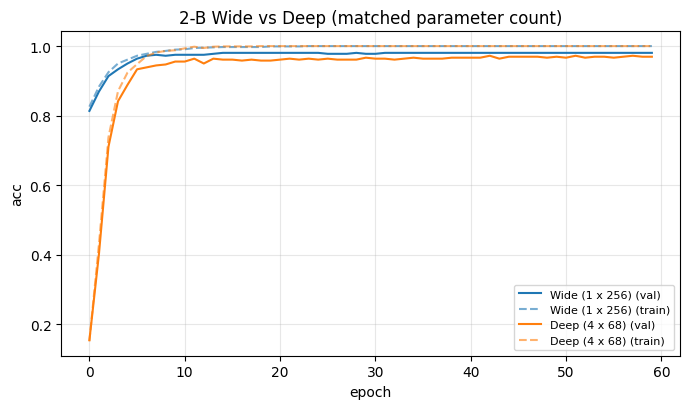


[여러 시드에서 반복]
  seed=0      wide=0.9778  deep=0.9639
  seed=1      wide=0.9750  deep=0.9694
  seed=42     wide=0.9722  deep=0.9639
  seed=2041   wide=0.9778  deep=0.9667
  seed=7777   wide=0.9722  deep=0.9528

Wide 평균 = 0.9750 (표준편차 0.0025)
Deep 평균 = 0.9633 (표준편차 0.0057)
Wide 가 이긴 횟수: 5 / 5


In [19]:
# ── 2-B. Wide vs Deep (파라미터 수를 맞춘 공정 비교) ─────────────

# (1) 파라미터 수 맞추기 — Deep 쪽 h 를 직접 찾으세요
H = 256
wide = build_mlp(hidden=(H,))
print(f"Wide 64-{H}-10 파라미터 수 = {count_params(wide)}")

# TODO: 은닉층 4개짜리 Deep 모델의 폭 h 를 정하라.
#       3h^2 + 78h + 10 이 위 숫자와 10% 이내가 되도록. (h 를 몇 개 넣어 보며 찾아도 좋다)
h = 68
deep = build_mlp(hidden=(h, h, h, h))
print(f"Deep 64-{h}x4-10 파라미터 수 = {count_params(deep)}")

diff_pct = abs(count_params(wide) - count_params(deep)) / count_params(wide) * 100
print(f"파라미터 수 차이 = {diff_pct:.2f}%  -> 10% 이내여야 공정한 비교")
assert diff_pct < 10, "파라미터 수가 10% 넘게 차이납니다. h 를 다시 고르세요."

# (2) 동일 조건으로 학습 후 비교
hist2b = {}
for tag, m in [(f"Wide (1 x {H})", wide), (f"Deep (4 x {h})", deep)]:
    hist2b[tag] = train_model(m, epochs=60)
    _, te_acc = evaluate(m, Xte, yte)
    print(f"{tag:<16} final val_acc = {hist2b[tag]['val_acc'][-1]:.4f} | "
          f"best val_acc = {max(hist2b[tag]['val_acc']):.4f} | test_acc = {te_acc:.4f} | "
          f"final train_loss = {hist2b[tag]['train_loss'][-1]:.4f}")

plot_curves(hist2b, "2-B Wide vs Deep (matched parameter count)", metric="acc")

# (3) 시드 하나로 결론 내지 않기 — 5개 시드에서 반복
print("\n[여러 시드에서 반복]")
wide_scores, deep_scores = [], []
for s in [0, 1, 42, MY_SEED, 7777]:
    w = build_mlp(hidden=(H,), seed=s)
    d = build_mlp(hidden=(h, h, h, h), seed=s)
    train_model(w, epochs=60, seed=s)
    train_model(d, epochs=60, seed=s)
    # TODO: 각 모델의 test accuracy 를 리스트에 담아라
    _, wacc = evaluate(w, Xte, yte)
    _, dacc = evaluate(d, Xte, yte)
    wide_scores.append(wacc)
    deep_scores.append(dacc)
    print(f"  seed={s:<6} wide={wide_scores[-1]:.4f}  deep={deep_scores[-1]:.4f}")

print(f"\nWide 평균 = {np.mean(wide_scores):.4f} (표준편차 {np.std(wide_scores):.4f})")
print(f"Deep 평균 = {np.mean(deep_scores):.4f} (표준편차 {np.std(deep_scores):.4f})")
print(f"Wide 가 이긴 횟수: {sum(w > d for w, d in zip(wide_scores, deep_scores))} / 5")

**Q2-B. (본인 출력값 인용 + 판단)**

**(1) 파라미터 맞추기.** 본인이 고른 `h`는 얼마이고 Deep의 파라미터 수는 몇 개인가요? Wide와 몇 % 차이인가요? **왜 파라미터 수를 맞춰야 공정한 비교**가 되는지 한 문장으로 쓰세요.
Wide 파라미터=19,210, Deep(h=68) 파라미터=19,186(0.12% 차이). 파라미터를 맞춰야 구조 차이인지 용량 차이인지 구분 가능하기 때문이다.

**(2) 단일 시드 결과.** Wide와 Deep의 test accuracy를 적으세요. 강의 p.36의 결론("Deep이 파라미터를 더 효율적으로 사용해 높은 성능")이 **본인 실험에서 재현되었나요?**
Wide test_acc=0.9778, Deep test_acc=0.9667. 강의에서의 결론이 재현되지 않음.


**(3) 5개 시드 결과.** Wide/Deep의 평균과 표준편차, 그리고 Wide가 이긴 횟수를 적으세요. 만약 (2)의 결론이 5개 시드에서도 유지된다면 **"시드 운"이 아니라는 근거**가 됩니다. 유지되었나요?
Wide 평균 0.9750(std 0.0025), Deep 평균 0.9633(std 0.0057), Wide 5/5 승.


**(4) 원인 추론 — 여기가 핵심입니다.** 결과가 강의와 달랐다면, 그 원인으로 다음 중 무엇을 의심하겠습니까? 최소 두 가지를 고르고 본인 데이터의 구체적 숫자로 근거를 대세요.
- (a) 데이터가 너무 작다 (훈련 샘플 몇 개인지 적을 것)
- (b) 입력이 8×8 = 64차원으로 단순해 계층적 특징이 필요 없다
- (c) Deep 쪽이 아직 수렴하지 않았다 (양쪽 `final train_loss`를 비교해 판단할 것)
- (d) 4층 정도로는 "Deep"이라 하기 부족하다
- (e) 규제·학습률을 Deep에 맞게 따로 튜닝하지 않았다

(a) train 1,078개로 데이터가 작음, (b) 64차원 입력이 단순해 계층적 특징이 불필요, (c)는 아님 : Deep의 final train_loss(0.00029)가 Wide(0.00295)보다 오히려 낮아 수렴 부족이 아니라 과적합/최적화 지형 문제에 가까움.

**(5) 조건을 붙여 다시 쓰기.** 강의 p.36의 문장을 **본인 실험 결과와 모순되지 않게** 조건을 붙여 고쳐 쓰세요. (예: "____ 한 조건에서는 Deep이 ____ 하다.") 그리고 실제로 Deep이 압도적으로 유리한 대표 사례를 강의 5장(Expansion into Modern AI)에서 하나 골라, **왜 그 도메인에서는 다른지** 한 문장으로 설명하세요.
digits처럼 입력이 단순하고 데이터가 1,000개 남짓인 조건에서는 Wide가 Deep보다 안정적이다. 반대로 CNN, ResNet 같은 대규모 이미지 도메인은 진짜 계층적 구조가 있어 Deep이 유리하다.

In [22]:
# ── 2-C. 나만의 최고 모델 ──────────────────────────────────────
# 규칙: 튜닝 판단은 반드시 val 로! test 는 맨 마지막 한 번만.

log = []   # (설명, 하이퍼파라미터, best_val_acc) 를 모두 기록 — 실패한 실험도 남길 것

def try_config(desc, hidden, act=nn.ReLU, p_drop=0.0, wd=0.0,
               opt_name="adam", lr=1e-3, epochs=80, batch_size=64):
    """조건 하나를 학습하고 val 성능을 기록한다. (test 는 건드리지 않는다)"""
    m = build_mlp(hidden=hidden, act=act, p_drop=p_drop)
    h = train_model(m, epochs=epochs, opt_name=opt_name, lr=lr,
                    weight_decay=wd, batch_size=batch_size)
    best_val = max(h["val_acc"])
    best_ep  = int(np.argmin(h["val_loss"])) + 1
    log.append((desc, best_val, best_ep, count_params(m)))
    print(f"{desc:<38} best_val_acc={best_val:.4f}  (val_loss 최저 ep={best_ep}, params={count_params(m)})")
    return m, h

# TODO: 본인 실험을 최소 4개 추가하세요. 아무거나 찍지 말고 '가설 -> 검증' 형태로.
#   예) 가설: §1.4처럼 L2 가 도움이 된다면 wd 를 키울수록 val 이 좋아질 것이다
#       try_config("C. Wide + wd=1e-3", hidden=(256,), wd=1e-3)
#   예) 가설: §2-B 에서 Wide 가 유리했으니 더 넓히면 더 좋아질 것이다
#       try_config("D. 더 넓게 (512,)", hidden=(512,))
try_config("A. baseline 재현 (64,32)", hidden=(64, 32))
try_config("B. Wide + 약한 L2", hidden=(256,), wd=1e-4)
try_config("C. Wide + L2 wd=1e-3", hidden=(256,), wd=1e-3)
try_config("D. 더 넓게 (512,)", hidden=(512,))
try_config("E. Wide(256) + Dropout p=0.3", hidden=(256,), p_drop=0.3)
try_config("F. Wide(256) + Momentum lr=0.05", hidden=(256,), opt_name="momentum", lr=0.05)


# ── 최종 선택 & 단 한 번의 test 평가 ──────────────────────────
print("\n" + "=" * 70)
print(f"{'실험':<40}{'best_val_acc':>14}{'best_ep':>9}{'params':>8}")
print("-" * 70)
for desc, bv, be, npar in sorted(log, key=lambda r: -r[1]):
    print(f"{desc:<40}{bv:>14.4f}{be:>9}{npar:>8}")

# TODO: 위 표에서 val 성능이 가장 좋았던 조건을 골라 아래에 그대로 다시 설정하라
FINAL_HIDDEN   = (256,)
FINAL_DROPOUT  = 0.0
FINAL_WD       = 0.0
FINAL_OPT      = "momentum"
FINAL_LR       = 0.05
FINAL_EPOCHS   = 80

final_model = build_mlp(hidden=FINAL_HIDDEN, p_drop=FINAL_DROPOUT)
final_hist  = train_model(final_model, epochs=FINAL_EPOCHS, opt_name=FINAL_OPT,
                          lr=FINAL_LR, weight_decay=FINAL_WD)

final_test_loss, final_test_acc = evaluate(final_model, Xte, yte)
print("\n" + "=" * 70)
print(f"[최종 모델] val 최고 = {max(final_hist['val_acc']):.4f}")
print(f"[최종 모델] TEST accuracy = {final_test_acc:.4f}  (baseline 대비 "
      f"{final_test_acc - test_acc:+.4f})")
print("=" * 70)

A. baseline 재현 (64,32)                 best_val_acc=0.9777  (val_loss 최저 ep=45, params=6570)
B. Wide + 약한 L2                        best_val_acc=0.9833  (val_loss 최저 ep=79, params=19210)
C. Wide + L2 wd=1e-3                   best_val_acc=0.9833  (val_loss 최저 ep=76, params=19210)
D. 더 넓게 (512,)                         best_val_acc=0.9833  (val_loss 최저 ep=55, params=38410)
E. Wide(256) + Dropout p=0.3           best_val_acc=0.9833  (val_loss 최저 ep=80, params=19210)
F. Wide(256) + Momentum lr=0.05        best_val_acc=0.9833  (val_loss 최저 ep=45, params=19210)

실험                                        best_val_acc  best_ep  params
----------------------------------------------------------------------
B. Wide + 약한 L2                                 0.9833       79   19210
C. Wide + L2 wd=1e-3                            0.9833       76   19210
D. 더 넓게 (512,)                                  0.9833       55   38410
E. Wide(256) + Dropout p=0.3                    0.9833       80   19210
F. Wi

**Q2-C. 전략 보고서 (텍스트로 서술)**

**(1) 실험 로그.** 위 표를 그대로 옮기고, **실패한 실험도 포함**해 최소 6개를 보고하세요.

실험                                        best_val_acc  best_ep  params
----------------------------------------------------------------------
B. Wide + 약한 L2                                 0.9833       79   19210
C. Wide + L2 wd=1e-3                            0.9833       76   19210
D. 더 넓게 (512,)                                  0.9833       55   38410
E. Wide(256) + Dropout p=0.3                    0.9833       80   19210
F. Wide(256) + Momentum lr=0.05                 0.9833       45   19210
A. baseline 재현 (64,32)                          0.9777       45    6570


**(2) 가설 → 검증.** 시도한 것 중 **가설이 맞았던 것 하나**와 **가설이 틀렸던 것 하나**를 골라, 각각 이렇게 정리하세요.
- 가설: "§2-B에서 Wide가 유리했으니 폭을 넓히면(256) baseline보다 좋아질 것이다. 왜냐하면 §2-B에서 Wide(256)이 파라미터 수가 비슷한 Deep보다 계속 이겼기 때문이다"
- 결과: val accuracy 0.9777(A, baseline) → 0.9833(B, 폭 256)
- 판정 및 해석: 가설 지지. digits에서는 폭을 넓히는 방향이 이 데이터 규모 안에서는 이득이 됐다.

- 가설: "§1.4에서 Dropout이 가장 좋았으니(작은 데이터에서 p=0.5가 best_val_acc 1위) 여기서도 Dropout을 걸면 baseline보다 확실히 더 좋아질 것이다."
- 결과: val accuracy 0.9777(A) → 0.9833(E, Dropout p=0.3)  다른 조건들과 동률이었을 뿐, 그 이상으로 특별히 더 좋아지진 않음
- 판정 및 해석: 가설 기각(부분적). §1.4는 train 150개짜리 극단적으로 과적합되기 쉬운 상황이었는데, 2-C는 train이 1,078개라 baseline조차 §1.4만큼 심하게 과적합하지 않아서 Dropout의 효과가 그때만큼 두드러지게 드러나지 않은 것 같다.

**(3) 최종 선택의 근거.** 왜 그 조건을 최종 모델로 골랐나요? **val 기준으로** 설명하세요.
F가 다른 동률 조건들과 val 성능은 같으면서 파라미터는 더 적거나 같고(19,210개, D의 절반) 수렴도 가장 빨랐다(best_ep=45)는 점에서 최종 모델로 선택했다.

**(4) val과 test의 간극.** 최종 모델의 best val accuracy와 test accuracy를 나란히 적으세요. 어느 쪽이 높나요? val이 test보다 높다면 그 이유는 무엇일까요? (힌트: val은 이미 **선택에 사용된** 데이터입니다.)

F의 best val accuracy는 0.9833, test accuracy는 0.9722로 val이 test보다 높다. val은 이미 어떤 설정이 좋은지를 고르는 데 여러 번 사용됐기 때문에 그 val 자체에 맞춘 선택 편향이 어느 정도 있을 수 있다. 이 test accuracy(0.9722)는 baseline의 test accuracy(0.9722)와 정확히 같게 나왔는데, test가 360개뿐이라 애초에 세세한 차이를 구분하기엔 표본이 작다는 점도 감안해야 할 것 같다.

**(5) 정직하게.** 만약 test를 여러 번 보면서 튜닝했다면, 그 test accuracy는 왜 **실제 성능의 과대평가**인가요? 이것이 §1.1에서 배운 데이터 누수와 어떻게 같은 문제인지 설명하세요.
test를 여러 번 보면서 튜닝했다면 그 test accuracy는 실제 성능을 과대평가하게 된다. 여러 조건을 test로 비교하면서 가장 잘 나온 test 점수를 고르는 순간, test는 더 이상 완전히 못 본 데이터가 아니라 사실상 튜닝에 쓰인 데이터가 되어버린다. StandardScaler를 test에 따로 fit하면 안 되는 이유와 마찬가지로, test의 정보가 모델 선택 과정에 새어 들어가면 그 test 점수는 더 이상 진짜 일반화 성능을 보여주지 못한다.

## 3. 결론

`digits`(1,797장, 8×8) 위에서 **데이터 준비 → MLP 학습 → 세 가지 고질병 실험 → 구조 비교**를 진행했습니다. 각 항목을 **본인이 뽑은 값**을 근거로 정리하세요.

- **기본 MLP 학습 (§1.2):** 모델의 파라미터 수와 test accuracy는 얼마였나요? train/val loss 곡선에서 Early Stopping이 필요해 보인 시점과 그 근거는? → (파라미터 수 6,570개, test accuracy 0.9722. train/val loss 곡선에서는 val_loss가 epoch 45에서 최저(0.0694)를 찍은 뒤 epoch 60에는 0.0709로 다시 올라갔고, train_acc는 이미 epoch 20쯤부터 1.0000이었다. train은 계속 좋아지는데 val이 45 epoch 근처부터 오히려 나빠지기 시작한 이 지점이 Early Stopping이 필요해 보인 시점이었다.)

- **Vanishing Gradient (§1.3):** Sigmoid 8층의 첫 층 gradient norm ____ vs 마지막 층 ____. 이 차이가 train accuracy ____로 이어진 인과를 한 문장으로: (Sigmoid 8층의 첫 층 gradient norm 1.95e-07 vs 마지막 층 3.11e-01. 이 차이가 train accuracy 0.2032(거의 학습 실패)로 이어진 인과는 입력에 가까운 층까지 gradient 신호가 사실상 도달하지 못해 그 층의 파라미터가 거의 업데이트되지 않았기 때문이다.)

- **Overfitting (§1.4):** baseline의 gap(val_loss − train_loss) = ____, Early Stopping 시점 = epoch ____. 네 처방 중 본인 데이터에서 최선이었던 것과 그 이유: (baseline의 gap(val_loss − train_loss) = 0.4894, Early Stopping 시점 = epoch 13. 네 처방 중 본인 데이터에서 최선이었던 건 Dropout p=0.5(best_val_acc 0.9053)였다)

- **Optimization (§1.5):** val 90% 도달 epoch — SGD ____ / Momentum ____ / Adam ____. "수렴 속도"와 "최종 성능"이 다른 이야기인 이유: (SGD 15 / Momentum 3 / Adam 8. 세 옵티마이저의 최종 val_acc는 0.97~0.98 사이로 거의 차이가 없었던 반면 90%까지 가는 속도는 최대 5배까지 차이가 났다. 옵티마이저는 주로 얼마나 빨리 도달하는가를 바꿀 뿐 도달 가능한 성능의 상한 자체를 크게 바꾸지는 않았다.)

- **구조 (§2-A, §2-B):** 활성화 함수를 없앴을 때 접기 오차 ____가 증명한 것은? 파라미터를 맞춘 Wide vs Deep에서 이긴 쪽과, 그 결과가 강의 슬라이드와 달랐다면 그 조건은? (활성화 함수가 없는 다층 네트워크는 아무리 층을 쌓아도 수학적으로 하나의 선형변환과 완전히 같은 함수라는 사실. 라미터를 맞춘 Wide vs Deep에서는 Wide가 5개 시드 모두(5/5) 이겼다.  깅ㅇ,; 지려와 다른 결과였고, digits처럼 입력이 단순하고 데이터가 작은(train 1,078개) 조건이 그 원인으로 보인다.)

- **한 문장 요약:** 이번 과제에서 **강의 슬라이드의 일반론이 본인 데이터에서는 성립하지 않았던 사례**를 하나 고르고, 거기서 배운 교훈을 한 문장으로: (Deep이 파라미터를 더 효율적으로 사용해 높은 성능을 낸다는 강의의 일반론이 digits처럼 작고 단순한 데이터에서는 성립하지 않았고, 여기서 얻은 교훈은 구조의 우월성은 데이터의 성격(크기·차원·계층적 구조 유무)에 따라 달라지므로 항상 데이터로 직접 검증해야 한다는 것이다.)

## 4. 회고


\(과제의 볼륨이 커서 세션 듣고 초반, 지난 주말에 중반까지, 과제 마감일인 오늘 마지막을 완성했다. 한 번 할때 시간을 길게 잡고 했으면 더 큰 인사이트를 얻었을 것 같은데 미루다 보니 이런 현상이 발생한 것이다.
처음엔 gradient가 작아진다는 걸 뺄셈처럼 층마다 조금씩 줄어드는 걸로 오해했는데, 실제로는 chain rule 때문에 각 층의 미분값이 곱셈으로 누적되는 구조였다. 그래서지수적 감소가 나온다는 걸 헷갈렸다.)

## 5. 생성형 AI 활용 (비판적 사용)

AI는 **검산기·설명 도우미**로 활용하고 최종 판단은 본인이 합니다.

- **어디에 썼나** (PyTorch 문법 디버깅·개념 설명·에러 해석 등 구체적으로): (2-B에서 오류가 나서 오류의 원인 및 해결방법을 물어보았다.)

- **AI가 이 실험에는 틀린 답을 준 사례** — 예를 들면 다음과 같은 오류가 자주 나옵니다.
  - 모델 마지막에 `nn.Softmax`를 붙이는 코드 (`CrossEntropyLoss`와 중복)
  - "학습률이 크면 항상 발산한다"고 조건 없이 단정
  - "Dropout을 쓰면 성능이 좋아진다"고 단정 (§1.4 본인 결과와 비교)
  - "Deep이 Wide보다 낫다"고 단정 (§2-B 5개 시드 결과와 비교)
  - 존재하지 않는 인자·API 이름을 사용하거나, 앞 셀에서 정의한 변수명(`train_model`, `hist_base` 등)을 무시

  본인이 겪은 사례와, 그것을 **어떻게 알아채고 고쳤는지**(본인 출력값과 대조 / 공식 문서 확인 / 직접 실험) 적으세요: (여기에 답)

- **실제 대화 내역** 붙여넣기:

```
오류가 난 이유를 설명하고, 어떻게 해결할 수 있는지 설명해줘.
```

- 마지막 한 문장: **AI가 대신할 수 없었던 나만의 판단**은? (판단이라기보다는, 실제로 돌려본 그 경험 자체는 AI가 대신할 수 없다.)
